In [1]:
import pandas as pd
import numpy as np
import shap
import warnings
import joblib
import sys
import psutil
import GPUtil
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, GroupKFold, cross_val_predict, ParameterGrid
from collections import defaultdict
from time import time
from datetime import timedelta
from importlib.metadata import version

# printout of python version
print("="*50, "Python Version", "="*50)
print(f"python version: {sys.version}")
print(f"xgboost:        {version('xgboost')}")
print(f"shap:           {version('shap')}")

# printout of hardware
print("="*50, "Hardware", "="*50)
gpus = GPUtil.getGPUs()
for gpu in gpus:
    print(f"GPU: {gpu.name}")
print(f"CPU cores: {psutil.cpu_count(logical=False)}")
print(f"RAM: {psutil.virtual_memory().total / 1024 / 1024 / 1024 :.2f} GB")

warnings.filterwarnings('ignore')

================================================== Python Version ==================================================
python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
xgboost:        2.1.1
shap:           0.46.0
================================================== Hardware ==================================================
GPU: NVIDIA GeForce RTX 4090
CPU cores: 16
RAM: 63.82 GB


# read data function 

In [2]:
def read_abcd(path, cols, na_values):
    
    df = pd.read_csv(path, sep='\t', index_col='subjectkey', na_values=na_values)
    df = df.drop(df.index[0])
    
    for col in cols:
        df[col] = pd.to_numeric(df[col])
        df = df[cols]

    df = df.reset_index()
    df = df.sort_values(['subjectkey', 'interview_age'])
    df = df.drop_duplicates(subset=['subjectkey'], keep='first')
    df = df.drop(columns=['interview_age'])
    df = df.set_index('subjectkey')
    
    df_show = abcd_ysu02.join(df)
    df_show = df_show.drop(columns=[
        'isip_1d_2',
        'isip_5_2',
        'isip_1b_yn'
    ])
     
    for col in df_show.columns:
        print('{:<30}    n = {:<10}    mean = {:<10.4f}    sum = {:<10.1f}'.\
              format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
    print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))
    
    return df

# y-target variable 

In [3]:
file_abcd_ysu02 = r'D:\gregn\data\ABCD\abcd3\abcd_ysu02.txt'
abcd_ysu02 = pd.read_csv(file_abcd_ysu02, sep='\t', index_col='subjectkey')
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02.index[0])
cols = [
    'interview_age',
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
]

for col in cols:
    abcd_ysu02[col] = pd.to_numeric(abcd_ysu02[col])
    abcd_ysu02 = abcd_ysu02[cols]
    
abcd_ysu02 = abcd_ysu02.reset_index()
abcd_ysu02 = abcd_ysu02.sort_values(['subjectkey', 'interview_age'])
abcd_ysu02 = abcd_ysu02.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_ysu02 = abcd_ysu02.drop(columns=['interview_age'])
abcd_ysu02 = abcd_ysu02.set_index('subjectkey')
    
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 3].index) # drop accidental 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 2].index) # drop furtive 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1b_yn == 0].index) # drop religious 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1d_2 > 10].index) # drop older than 10

abcd_ysu02['isip_1d_2'] = abcd_ysu02['isip_1d_2'].fillna(0)

y = abcd_ysu02['isip_1d_2'].values
y = np.where(y>0, 1, y)

unique, counts = np.unique(y, return_counts=True)

print('number of subjects: {:>10}\n\n[0] never sipped: {:>12}\n[1] sipped by age 10:{:>9}'.\
      format(len(y), counts[0], counts[1]))

number of subjects:      10707

[0] never sipped:         9209
[1] sipped by age 10:     1498


# pdem02

In [4]:
file_pdem02 = r'D:\gregn\data\ABCD\abcd3\pdem02.txt'
pdem02 = pd.read_csv(file_pdem02, sep='\t', index_col='subjectkey', na_values=['777', '999'])
pdem02 = pdem02.drop(pdem02.index[0])

cols = [
    'interview_age',
    'demo_prim',
    'demo_adopt_agex_v2',
    'demo_sex_v2',
    'demo_gender_id_v2',
    'demo_prnt_age_v2',
    'demo_prnt_gender_id_v2',
    'demo_prnt_marital_v2',
    'demo_prnt_ed_v2',
    'demo_prnt_empl_v2',
    'demo_prnt_empl_time',
    'demo_prnt_income_v2',
    'demo_prnt_prtnr_v2',
    'demo_comb_income_v2',
    'demo_fam_exp1_v2',
    'demo_fam_exp2_v2',
    'demo_fam_exp3_v2',
    'demo_fam_exp4_v2',
    'demo_fam_exp5_v2',
    'demo_fam_exp6_v2',
    'demo_fam_exp7_v2'
]

for col in cols:
    pdem02[col] = pd.to_numeric(pdem02[col])
    pdem02 = pdem02[cols]
    
pdem02 = pd.get_dummies(pdem02, columns=[
    'demo_prim',
    'demo_sex_v2',
    'demo_gender_id_v2',
    'demo_prnt_gender_id_v2',
    'demo_prnt_marital_v2',
    'demo_prnt_empl_v2',
], dtype=float)

pdem02 = pdem02.rename(columns={
    'demo_prim_1': 'demo_prim_biological_mother',
    'demo_prim_2': 'demo_prim_biological_father',
    'demo_prim_3': 'demo_prim_adoptive_parent',
    'demo_prim_4': 'demo_prim_custodial_parent',
    'demo_prim_5': 'demo_prim_other',
    'demo_sex_v2_1': 'demo_sex_v2_male',
    'demo_sex_v2_2': 'demo_sex_v2_female',
    'demo_sex_v2_3': 'demo_sex_v2_intersex-male', 
    'demo_gender_id_v2_1.0': 'demo_gender_id_v2_male',
    'demo_gender_id_v2_2.0': 'demo_gender_id_v2_female',
    'demo_gender_id_v2_3.0': 'demo_gender_id_v2_trans_male',
    'demo_gender_id_v2_4.0': 'demo_gender_id_v2_trans_female',
    'demo_gender_id_v2_5.0': 'demo_gender_id_v2_gender_queer',
    'demo_gender_id_v2_6.0': 'demo_gender_id_v2_different',
    'demo_prnt_gender_id_v2_1.0': 'demo_prnt_gender_id_v2_male',
    'demo_prnt_gender_id_v2_2.0': 'demo_prnt_gender_id_v2_female',
    'demo_prnt_gender_id_v2_3.0': 'demo_prnt_gender_id_v2_trans_male',
    'demo_prnt_gender_id_v2_4.0': 'demo_prnt_gender_id_v2_trans_female',
    'demo_prnt_gender_id_v2_5.0': 'demo_prnt_gender_id_v2_gender_queer',
    'demo_prnt_gender_id_v2_6.0': 'demo_prnt_gender_id_v2_different',
    'demo_prnt_marital_v2_1.0': 'demo_prnt_marital_v2_married',
    'demo_prnt_marital_v2_2.0': 'demo_prnt_marital_v2_widowed',
    'demo_prnt_marital_v2_3.0': 'demo_prnt_marital_v2_divorced',
    'demo_prnt_marital_v2_4.0': 'demo_prnt_marital_v2_separated',
    'demo_prnt_marital_v2_5.0': 'demo_prnt_marital_v2_never_married',
    'demo_prnt_marital_v2_6.0': 'demo_prnt_marital_v2_living_with_partner',
    'demo_prnt_empl_v2_1.0': 'demo_prnt_empl_v2_working_now',
    'demo_prnt_empl_v2_2.0': 'demo_prnt_empl_v2_temporarily_laid_off',
    'demo_prnt_empl_v2_3.0': 'demo_prnt_empl_v2_looking_for_work',
    'demo_prnt_empl_v2_4.0': 'demo_prnt_empl_v2_retired',
    'demo_prnt_empl_v2_5.0': 'demo_prnt_empl_v2_disabled',
    'demo_prnt_empl_v2_6.0': 'demo_prnt_empl_v2_stay_at_home_parent',
    'demo_prnt_empl_v2_7.0': 'demo_prnt_empl_v2_student',
    'demo_prnt_empl_v2_8.0': 'demo_prnt_empl_v2_other',
    'demo_prnt_empl_v2_9.0': 'demo_prnt_empl_v2_sick_leave',
    'demo_prnt_empl_v2_10.0': 'demo_prnt_empl_v2_maternity_leave',
    'demo_prnt_empl_v2_11.0': 'demo_prnt_empl_v2_unemployed_not_looking'   
})


pdem02['demo_gender_id_v2_non-binary'] = (pdem02.demo_gender_id_v2_trans_male
                                         + pdem02.demo_gender_id_v2_trans_female
                                         + pdem02.demo_gender_id_v2_gender_queer
                                         + pdem02.demo_gender_id_v2_different)

pdem02['demo_prnt_gender_id_v2_non-binary'] = (pdem02.demo_prnt_gender_id_v2_trans_male
                                              + pdem02.demo_prnt_gender_id_v2_trans_female
                                              + pdem02.demo_prnt_gender_id_v2_gender_queer
                                              + pdem02.demo_prnt_gender_id_v2_different)


pdem02 = pdem02.drop(columns=[
    'demo_gender_id_v2_trans_male',
    'demo_gender_id_v2_trans_female',
    'demo_gender_id_v2_gender_queer',
    'demo_gender_id_v2_different',
    'demo_prnt_gender_id_v2_trans_male',
    'demo_prnt_gender_id_v2_trans_female',
    'demo_prnt_gender_id_v2_gender_queer',
    'demo_prnt_gender_id_v2_different',
    'demo_sex_v2_intersex-male'
])

pdem02 = pdem02.reset_index()
pdem02 = pdem02.sort_values(['subjectkey', 'interview_age'])
pdem02 = pdem02.drop_duplicates(subset=['subjectkey'], keep='first')
#pdem02 = pdem02.drop(columns=['interview_age'])
pdem02 = pdem02.set_index('subjectkey')

df_show = abcd_ysu02.join(pdem02)
df_show = df_show.drop(columns=[
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
])

for col in df_show.columns:
    print('{:<40}    n = {:<10}    mean = {:<10.4f}    sum = {:<10}'.\
          format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))

interview_age                               n = 10707         mean = 118.8987      sum = 1273048   
demo_adopt_agex_v2                          n = 252           mean = 2.2289        sum = 561.68    
demo_prnt_age_v2                            n = 10620         mean = 39.8566       sum = 423277.1  
demo_prnt_ed_v2                             n = 10692         mean = 16.5397       sum = 176843.0  
demo_prnt_empl_time                         n = 7314          mean = 1.2740        sum = 9318.0    
demo_prnt_income_v2                         n = 9699          mean = 4.8610        sum = 47147.0   
demo_prnt_prtnr_v2                          n = 10594         mean = 1.1937        sum = 12646.0   
demo_comb_income_v2                         n = 9772          mean = 7.1823        sum = 70185.0   
demo_fam_exp1_v2                            n = 10632         mean = 0.0837        sum = 890.0     
demo_fam_exp2_v2                            n = 10661         mean = 0.0623        sum = 664.0     


In [5]:
pdem02 = pdem02['demo_sex_v2_male']
pdem02

subjectkey
NDARMC003PZF        0.0
NDAR_INV003RTV85    0.0
NDAR_INV005V6D2C    0.0
NDAR_INV007W6H7B    1.0
NDAR_INV00BD7VDC    1.0
                   ... 
NDAR_INVZZNX6W2P    1.0
NDAR_INVZZPKBDAC    0.0
NDAR_INVZZZ2ALR6    0.0
NDAR_INVZZZNB0XC    0.0
NDAR_INVZZZP87KR    0.0
Name: demo_sex_v2_male, Length: 11878, dtype: float64

# abcd_meim01

In [6]:
file_abcd_meim01 = r'D:\gregn\data\ABCD\abcd3\abcd_meim01.txt'
abcd_meim01 = pd.read_csv(file_abcd_meim01, sep='\t', index_col='subjectkey', na_values=['777', '999'])
abcd_meim01 = abcd_meim01.drop(abcd_meim01.index[0])

cols = [
    'interview_age',
    'meim_ethnic_id_p',
]

for col in cols:
    abcd_meim01[col] = pd.to_numeric(abcd_meim01[col])
    abcd_meim01 = abcd_meim01[cols]

abcd_meim01 = pd.get_dummies(abcd_meim01, columns=['meim_ethnic_id_p'], dtype=float)

abcd_meim01 = abcd_meim01.rename(columns={
    'meim_ethnic_id_p_0.0': 'meim_ethnic_id_p_none',
    'meim_ethnic_id_p_1.0': 'meim_ethnic_id_p_white/caucasian',
    'meim_ethnic_id_p_2.0': 'meim_ethnic_id_p_western_european',
    'meim_ethnic_id_p_3.0': 'meim_ethnic_id_p_eastern_european',
    'meim_ethnic_id_p_4.0': 'meim_ethnic_id_p_hispanic/latino',
    'meim_ethnic_id_p_5.0': 'meim_ethnic_id_p_black/african_american',
    'meim_ethnic_id_p_6.0': 'meim_ethnic_id_p_afro-carribean/indo-carribbean/west_indian',
    'meim_ethnic_id_p_7.0': 'meim_ethnic_id_p_east_asian',
    'meim_ethnic_id_p_8.0': 'meim_ethnic_id_p_south_asian',
    'meim_ethnic_id_p_9.0': 'meim_ethnic_id_p_southeast_asian',
    'meim_ethnic_id_p_10.0': 'meim_ethnic_id_p_american_indian/alaska_native',
    'meim_ethnic_id_p_11.0': 'meim_ethnic_id_p_middle_eastern/north_african',
    'meim_ethnic_id_p_12.0': 'meim_ethnic_id_p_native_hawaiian_or_pacific_islander',
    'meim_ethnic_id_p_13.0': 'meim_ethnic_id_p_mixed',
    'meim_ethnic_id_p_14.0': 'meim_ethnic_id_p_other'
})

abcd_meim01 = abcd_meim01.reset_index()
abcd_meim01 = abcd_meim01.sort_values(['subjectkey', 'interview_age'])
abcd_meim01 = abcd_meim01.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_meim01 = abcd_meim01.drop(columns=['interview_age'])
abcd_meim01 = abcd_meim01.set_index('subjectkey')

df_show = abcd_ysu02.join(abcd_meim01)
df_show = df_show.drop(columns=[
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
])

for col in df_show.columns:
    print('{:<60}    n = {:<10}    mean = {:<10.4f}    sum = {:<10}'.\
          format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))

meim_ethnic_id_p_none                                           n = 10707         mean = 0.0663        sum = 710.0     
meim_ethnic_id_p_white/caucasian                                n = 10707         mean = 0.5314        sum = 5690.0    
meim_ethnic_id_p_western_european                               n = 10707         mean = 0.0128        sum = 137.0     
meim_ethnic_id_p_eastern_european                               n = 10707         mean = 0.0040        sum = 43.0      
meim_ethnic_id_p_hispanic/latino                                n = 10707         mean = 0.1455        sum = 1558.0    
meim_ethnic_id_p_black/african_american                         n = 10707         mean = 0.1454        sum = 1557.0    
meim_ethnic_id_p_afro-carribean/indo-carribbean/west_indian     n = 10707         mean = 0.0028        sum = 30.0      
meim_ethnic_id_p_east_asian                                     n = 10707         mean = 0.0182        sum = 195.0     
meim_ethnic_id_p_south_asian            

# abcd_lt01

In [7]:
file_abcd_lt01 = r'D:\gregn\data\ABCD\abcd3\abcd_lt01.txt'

abcd_lt01 = pd.read_csv(file_abcd_lt01, sep='\t', index_col='subjectkey')
abcd_lt01 = abcd_lt01.drop(abcd_lt01.index[0])

cols = [
    'interview_age',
    'site_id_l'
]

abcd_lt01 = pd.get_dummies(abcd_lt01, columns=['site_id_l'], dtype=float)

abcd_lt01 = abcd_lt01.reset_index()
abcd_lt01 = abcd_lt01.sort_values(['subjectkey', 'interview_age'])
abcd_lt01 = abcd_lt01.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_lt01 = abcd_lt01.drop(columns=['interview_age'])
abcd_lt01 = abcd_lt01.set_index('subjectkey')

abcd_lt01 = abcd_lt01.iloc[:, 8:]

df_show = abcd_ysu02.join(abcd_lt01)
df_show = df_show.drop(columns=[
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
])

for col in df_show.columns:
    print('{:<40}    n = {:<10}    mean = {:<10.4f}    sum = {:<10}'.\
          format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))

site_id_l_site01                            n = 10707         mean = 0.0345        sum = 369.0     
site_id_l_site02                            n = 10707         mean = 0.0468        sum = 501.0     
site_id_l_site03                            n = 10707         mean = 0.0531        sum = 569.0     
site_id_l_site04                            n = 10707         mean = 0.0616        sum = 660.0     
site_id_l_site05                            n = 10707         mean = 0.0311        sum = 333.0     
site_id_l_site06                            n = 10707         mean = 0.0497        sum = 532.0     
site_id_l_site07                            n = 10707         mean = 0.0280        sum = 300.0     
site_id_l_site08                            n = 10707         mean = 0.0289        sum = 309.0     
site_id_l_site09                            n = 10707         mean = 0.0357        sum = 382.0     
site_id_l_site10                            n = 10707         mean = 0.0616        sum = 660.0     


# acspsw03

In [8]:
path = r'D:\gregn\data\ABCD\abcd3\acspsw03.txt'

cols = [
    'interview_age',
    'rel_family_id',

]

na_values = [None]
acspsw03 = read_abcd(path, cols, na_values)

rel_family_id                     n = 10707         mean = 5921.1416     sum = 63397663.0

subjects:     10707
features:         1


# join dataframes

In [9]:
dfs = [
    abcd_ysu02,
    pdem02,
    abcd_meim01,
    acspsw03,
    abcd_lt01,
]

abcd = dfs[0].join(dfs[1:])
print('number of subjects:', len(abcd))

number of subjects: 10707


# X features

In [10]:
X = abcd.drop(columns=[
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn',
    'rel_family_id'
])
X_values = X.values
print('number of features:', X.shape[1])
list(X.columns)

number of features: 38


['demo_sex_v2_male',
 'meim_ethnic_id_p_none',
 'meim_ethnic_id_p_white/caucasian',
 'meim_ethnic_id_p_western_european',
 'meim_ethnic_id_p_eastern_european',
 'meim_ethnic_id_p_hispanic/latino',
 'meim_ethnic_id_p_black/african_american',
 'meim_ethnic_id_p_afro-carribean/indo-carribbean/west_indian',
 'meim_ethnic_id_p_east_asian',
 'meim_ethnic_id_p_south_asian',
 'meim_ethnic_id_p_southeast_asian',
 'meim_ethnic_id_p_american_indian/alaska_native',
 'meim_ethnic_id_p_middle_eastern/north_african',
 'meim_ethnic_id_p_native_hawaiian_or_pacific_islander',
 'meim_ethnic_id_p_mixed',
 'meim_ethnic_id_p_other',
 'site_id_l_site01',
 'site_id_l_site02',
 'site_id_l_site03',
 'site_id_l_site04',
 'site_id_l_site05',
 'site_id_l_site06',
 'site_id_l_site07',
 'site_id_l_site08',
 'site_id_l_site09',
 'site_id_l_site10',
 'site_id_l_site11',
 'site_id_l_site12',
 'site_id_l_site13',
 'site_id_l_site14',
 'site_id_l_site15',
 'site_id_l_site16',
 'site_id_l_site17',
 'site_id_l_site18',
 's

# repeated nested cross validation 


Run 1
8 grid search candidates

Runtime for run 1: 0:04:54.146053

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550344228744507

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206713  17.896669   17.896669
1   meim_ethnic_id_p_black/african_american    0.193198  16.726641   34.623310
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611745   44.235054
3                          demo_sex_v2_male    0.098835   8.556858   52.791912
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

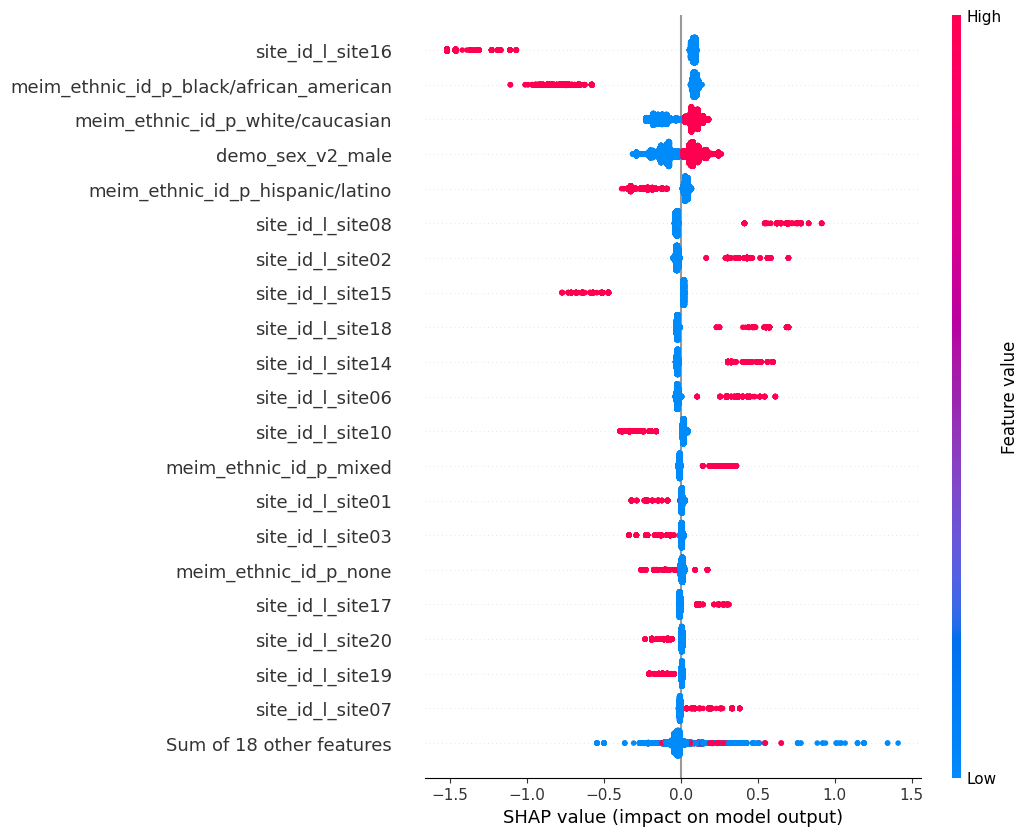


Run 2
8 grid search candidates

Runtime for run 2: 0:04:53.515327

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550335884094238

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206712  17.896618   17.896618
1   meim_ethnic_id_p_black/african_american    0.193198  16.726627   34.623245
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611771   44.235016
3                          demo_sex_v2_male    0.098835   8.556885   52.791901
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

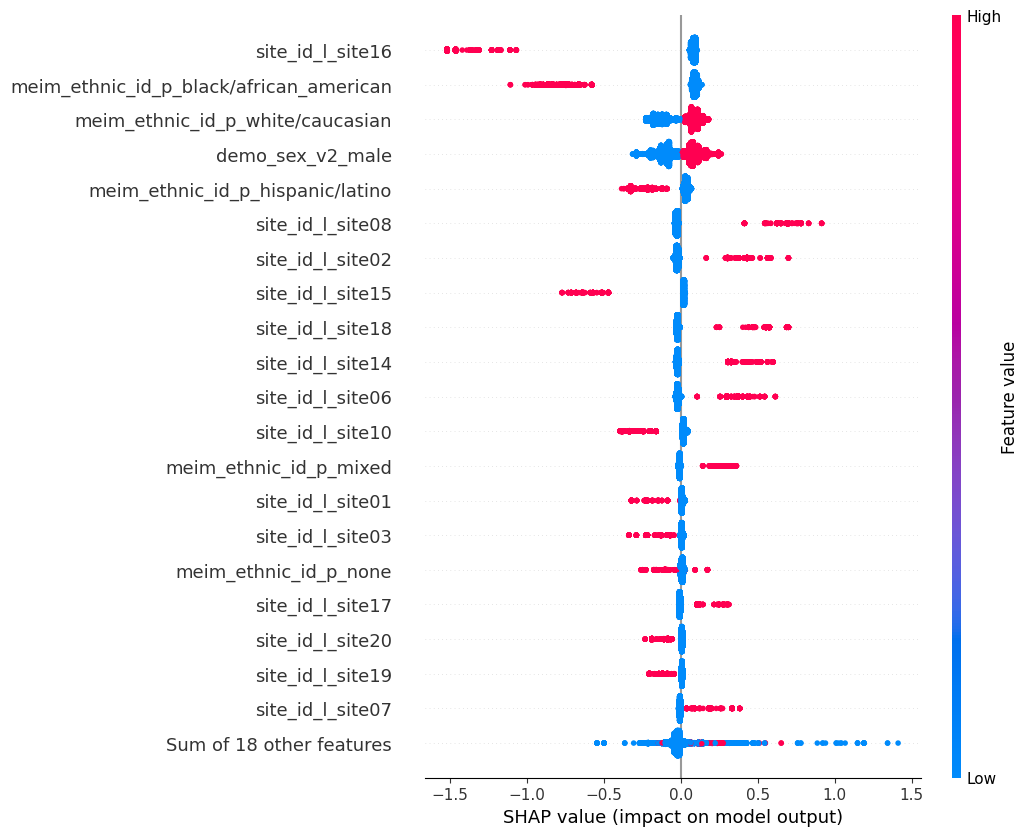


Run 3
8 grid search candidates

Runtime for run 3: 0:04:53.450443

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550345420837402

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206713  17.896669   17.896669
1   meim_ethnic_id_p_black/african_american    0.193198  16.726639   34.623306
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611754   44.235062
3                          demo_sex_v2_male    0.098835   8.556855   52.791916
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

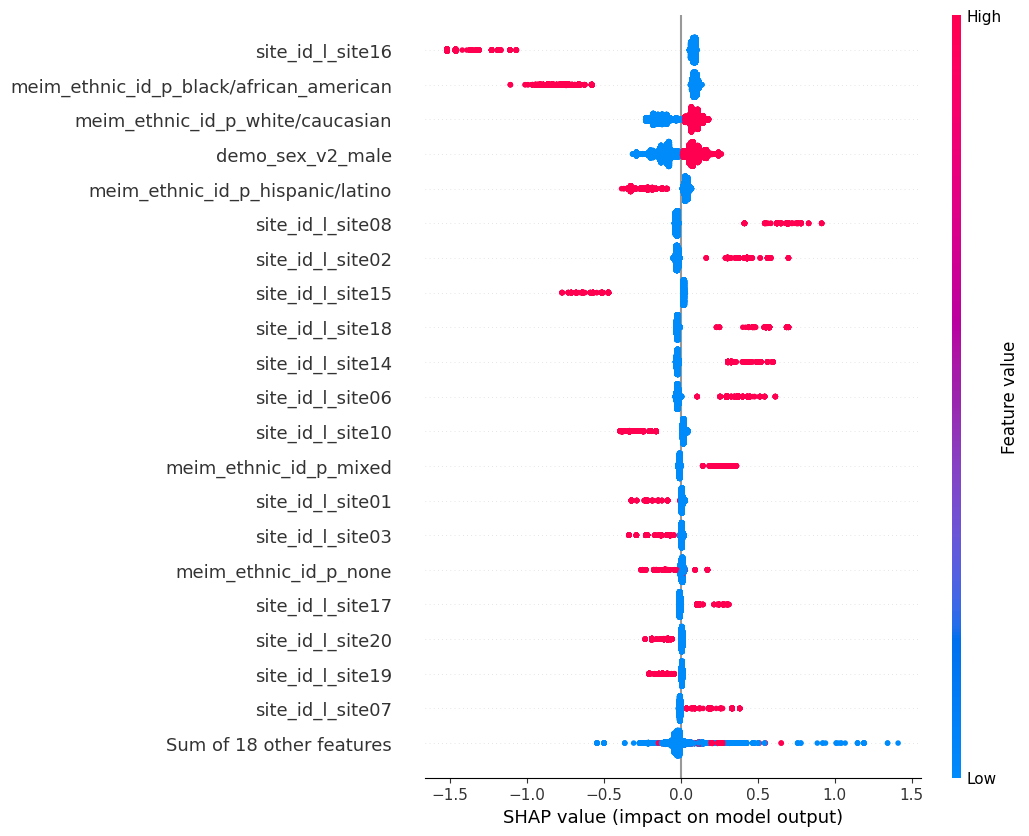


Run 4
8 grid search candidates

Runtime for run 4: 0:04:53.806728

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550337076187134

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206712  17.896656   17.896656
1   meim_ethnic_id_p_black/african_american    0.193198  16.726635   34.623291
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611770   44.235062
3                          demo_sex_v2_male    0.098835   8.556858   52.791920
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

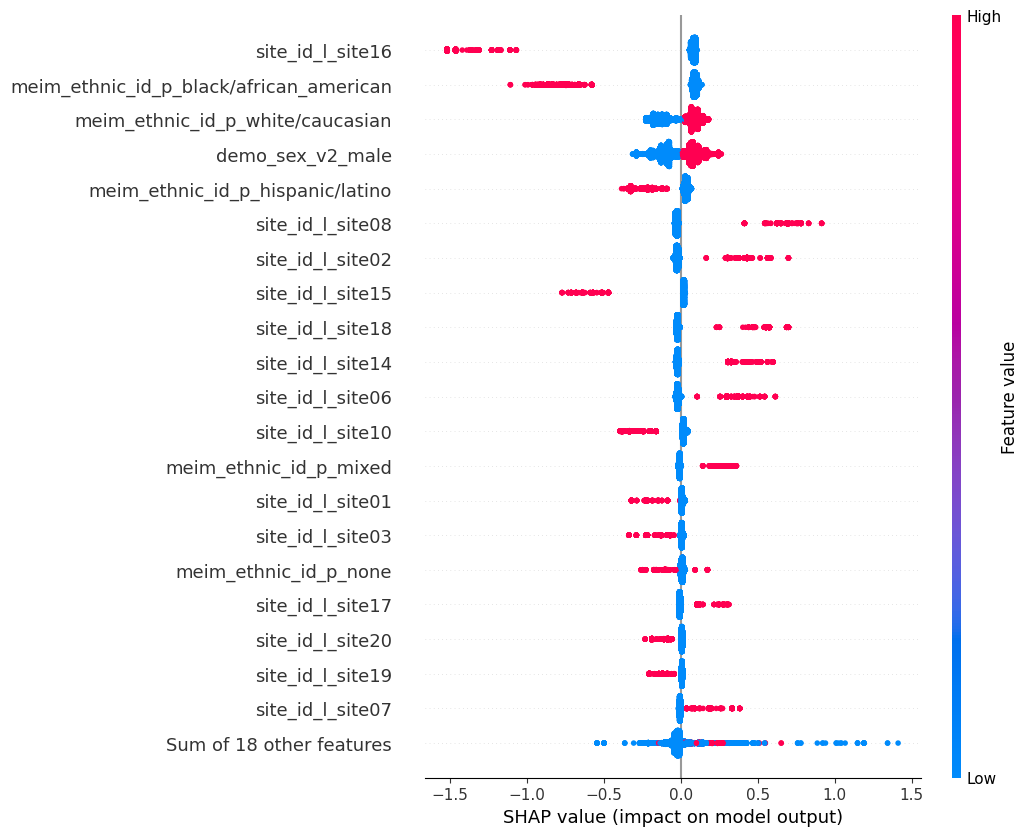


Run 5
8 grid search candidates

Runtime for run 5: 0:05:00.718775

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550333499908447

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206712  17.896643   17.896643
1   meim_ethnic_id_p_black/african_american    0.193198  16.726614   34.623257
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611755   44.235012
3                          demo_sex_v2_male    0.098835   8.556866   52.791878
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

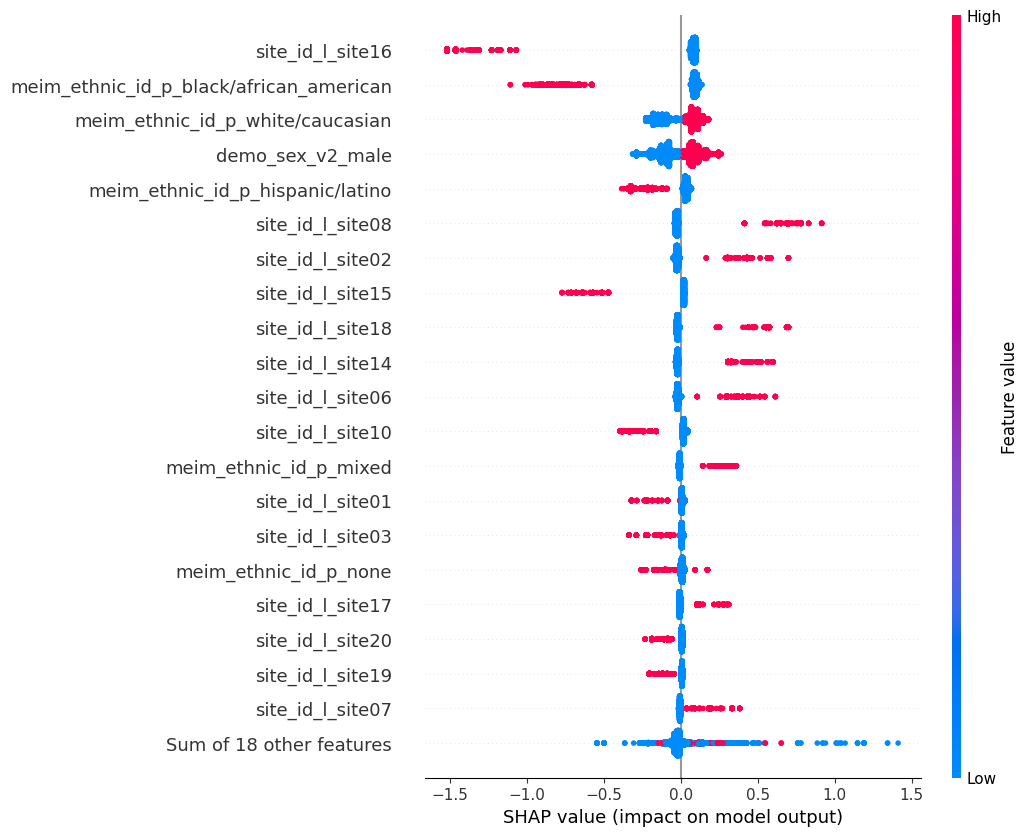


Run 6
8 grid search candidates

Runtime for run 6: 0:04:56.825088

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550346612930298

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206713  17.896698   17.896698
1   meim_ethnic_id_p_black/african_american    0.193198  16.726606   34.623306
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611768   44.235073
3                          demo_sex_v2_male    0.098835   8.556862   52.791935
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

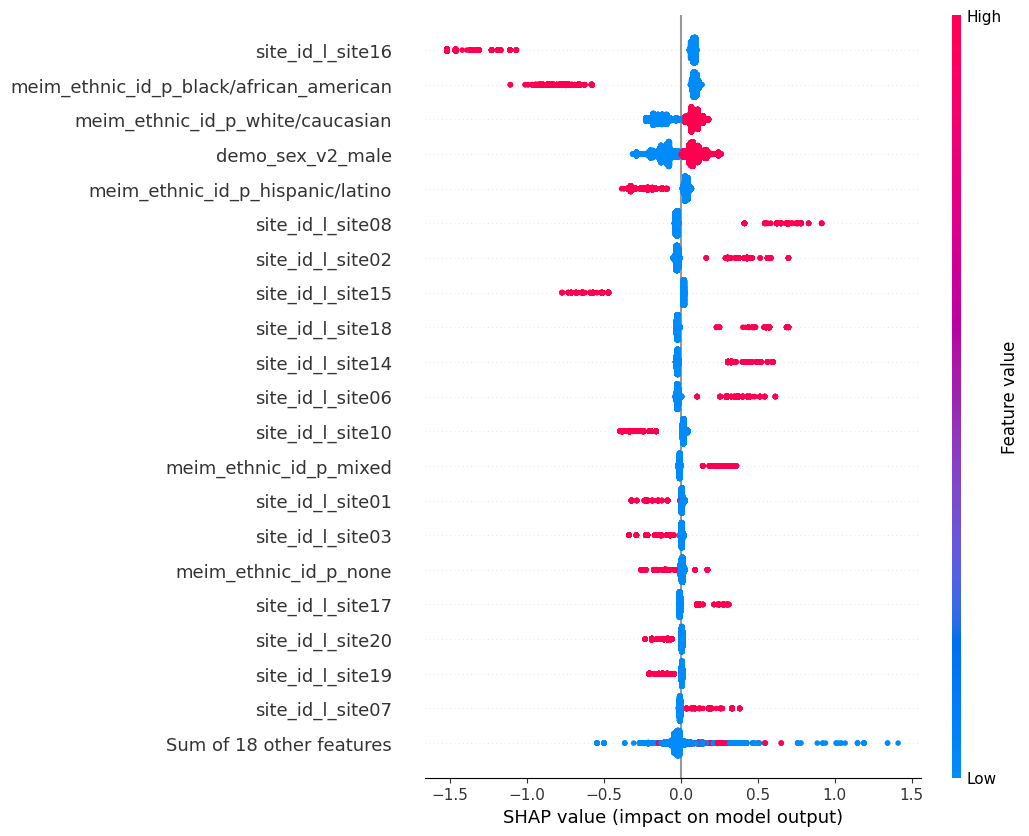


Run 7
8 grid search candidates

Runtime for run 7: 0:04:55.380497

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550337076187134

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206713  17.896696   17.896696
1   meim_ethnic_id_p_black/african_american    0.193198  16.726618   34.623314
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611728   44.235043
3                          demo_sex_v2_male    0.098835   8.556884   52.791927
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

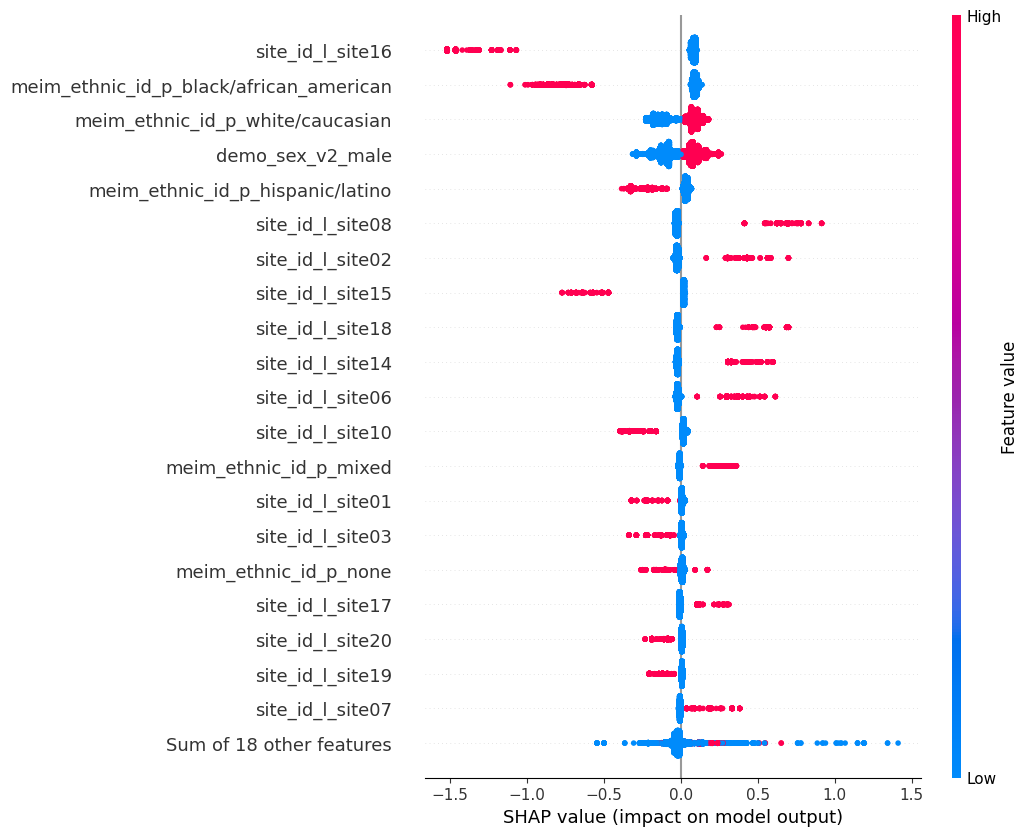


Run 8
8 grid search candidates

Runtime for run 8: 0:04:55.893844

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550341844558716

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206712  17.896601   17.896601
1   meim_ethnic_id_p_black/african_american    0.193199  16.726646   34.623245
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611786   44.235031
3                          demo_sex_v2_male    0.098835   8.556871   52.791901
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

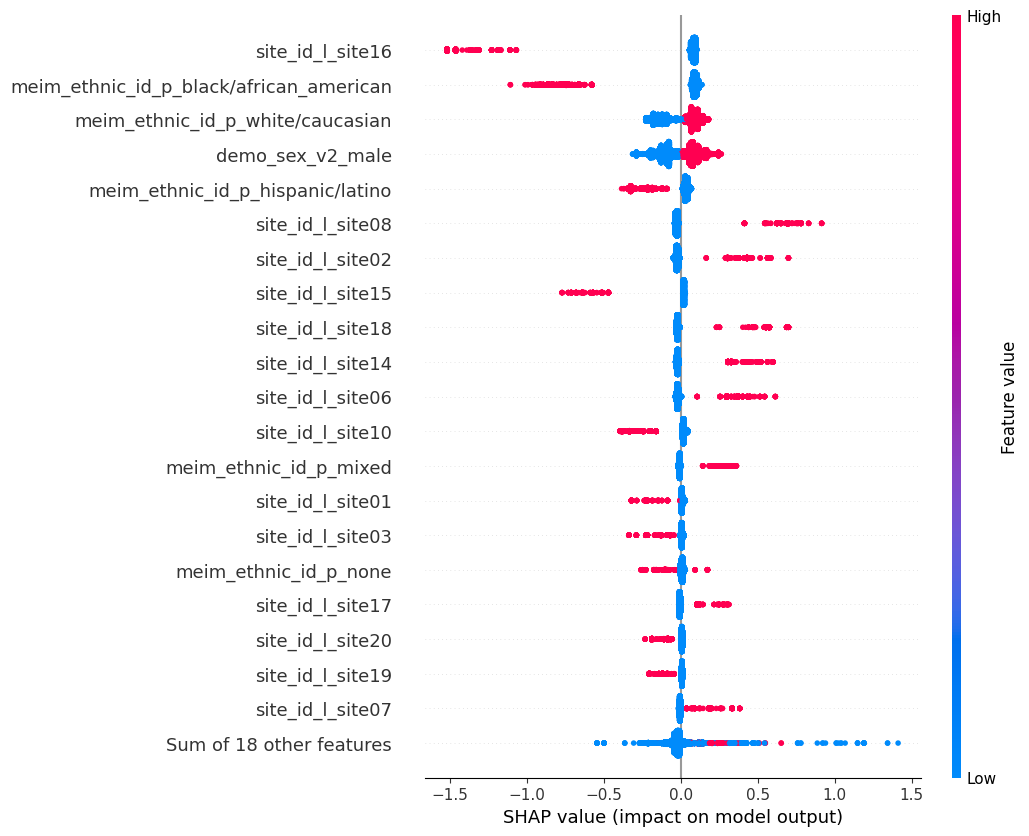


Run 9
8 grid search candidates

Runtime for run 9: 0:05:03.478781

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550352573394775

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206713  17.896673   17.896673
1   meim_ethnic_id_p_black/african_american    0.193199  16.726633   34.623306
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611773   44.235077
3                          demo_sex_v2_male    0.098835   8.556875   52.791954
4          meim_ethnic_id_p_hispanic/latino    0.067276   5

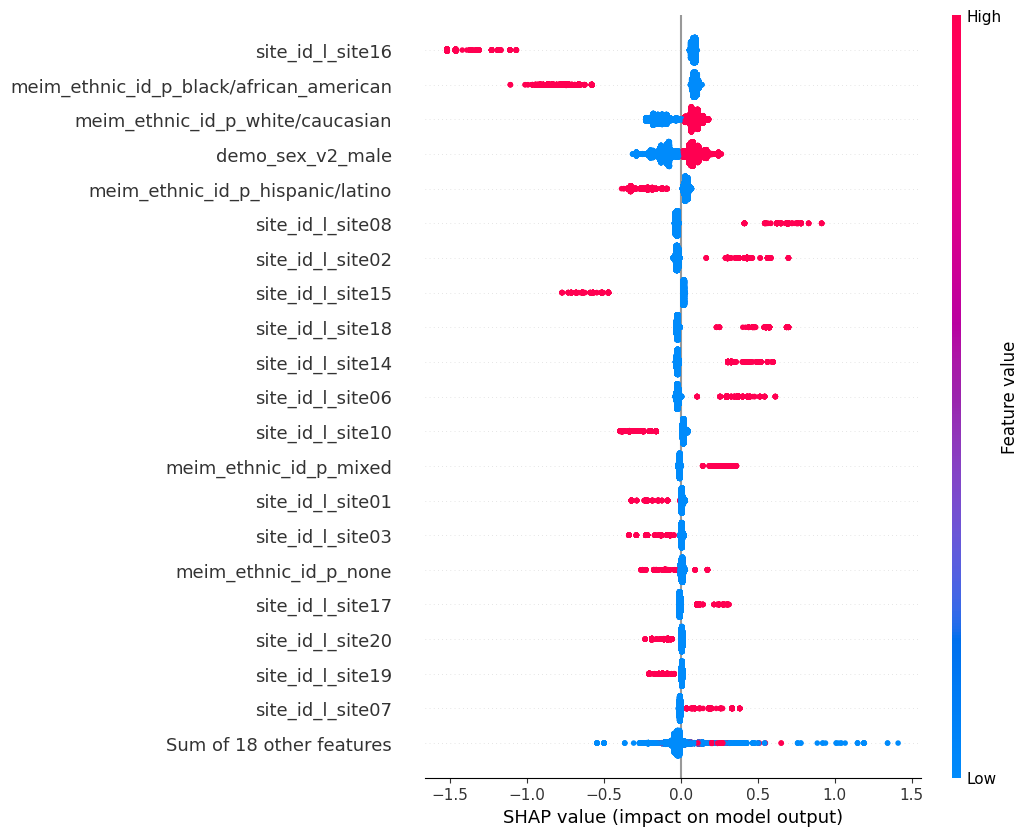


Run 10
8 grid search candidates

Runtime for run 10: 0:04:58.293772

Average ROC AUC score:   0.6870 [0.67656895 0.68941097 0.69556684 0.67782402 0.69545718]
Average accuracy score:  0.8598 [0.85994398 0.85994398 0.86034563 0.86034563 0.85847735]
Average precision score: 0.0000 [0. 0. 0. 0. 0.]
Average recall score:    0.0000 [0. 0. 0. 0. 0.]
Average F1 score:        0.0000 [0. 0. 0. 0. 0.]

Best parameters: {'learning_rate': 0.005, 'max_depth': 8, 'n_estimators': 1000}

Sum of SHAP values: 1.1550339460372925

Top 20 features by SHAP value:
                                    feature  SHAP value    percent  cumulative
0                          site_id_l_site16    0.206713  17.896669   17.896669
1   meim_ethnic_id_p_black/african_american    0.193198  16.726612   34.623283
2          meim_ethnic_id_p_white/caucasian    0.111019   9.611775   44.235058
3                          demo_sex_v2_male    0.098835   8.556852   52.791908
4          meim_ethnic_id_p_hispanic/latino    0.067276  

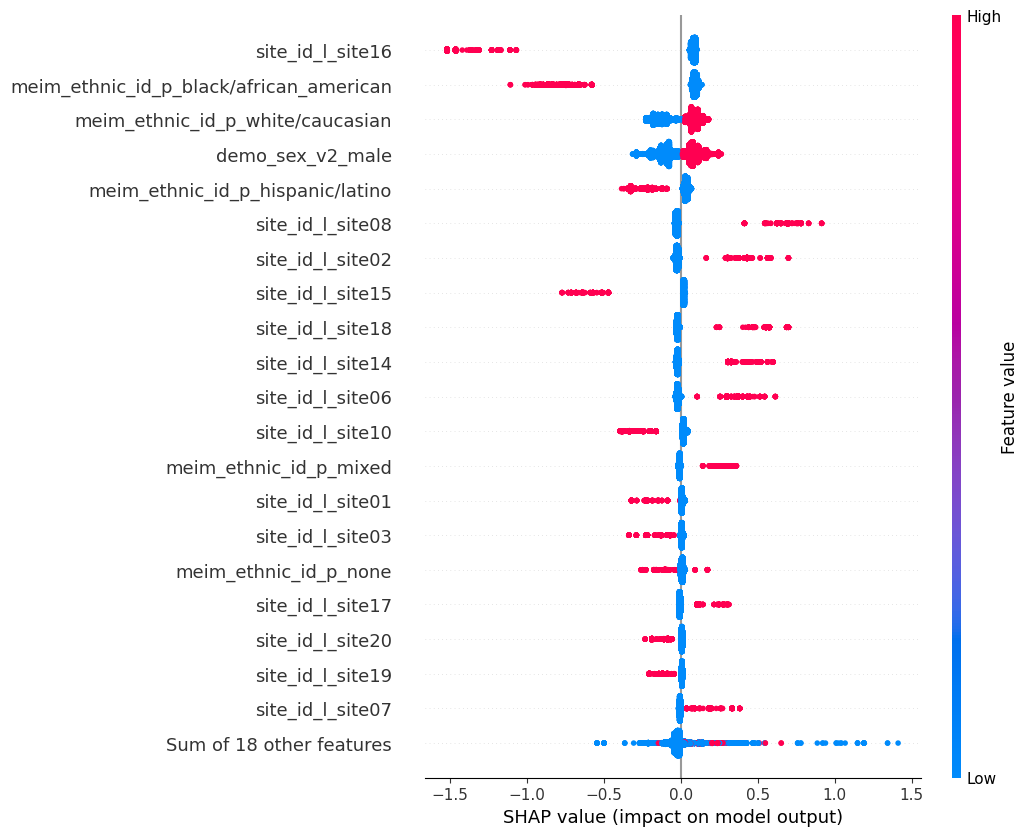


Total runtime for all runs: 1:31:22.233621


In [11]:
def run_nested_cv(num_runs=10):
    overall_start = time()
    
    # define the hyperparameter grid and scoring metrics
    params = {
        'learning_rate': [0.005, 0.01],
        'max_depth': [4, 8],
        'n_estimators': [500, 1000],

    }
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
       
    for run in range(1, num_runs+1):
        print(f"\n{'='*60}\nRun {run}\n{'='*60}")
        run_start = time()
        
        # shuffle the data before assigning family_groups
        perm = np.random.permutation(len(y))
        X_values_shuffled = X_values[perm]
        y_shuffled = y[perm]
        # shuffle the abcd dataframe so we can recompute family_groups from the family id column
        abcd_shuffled = abcd.iloc[perm].reset_index(drop=True)
        
        # recompute family groups from the shuffled 'rel_family_id' column
        d = defaultdict(lambda: len(d))
        family_groups_shuffled = np.array([d[x] for x in abcd_shuffled['rel_family_id']])
        
        # create a new model for each run 
        model = XGBClassifier(
            tree_method='gpu_hist',
            objective='binary:logistic',
            eval_metric='auc',
            colsample_bytree=0.4
        )
        
        # inner loop 
        inner_cv = GroupKFold(n_splits=5)
        inner_cv = inner_cv.get_n_splits(X_values, y, groups=family_groups_shuffled)

        # outer loop
        outer_cv = GroupKFold(n_splits=5)
        outer_cv = outer_cv.get_n_splits(X_values, y, groups=family_groups_shuffled)
        
        # setup GridSearchCV
        gs = GridSearchCV(
            estimator=model, 
            param_grid=params, 
            scoring='roc_auc', 
            cv=inner_cv,
            return_train_score=True,
            verbose=0  
        )
        
        # fit GridSearchCV 
        gs.fit(X_values, y)
        
        # run nested CV using cross_validate
        nested_scores = cross_validate(
            gs,
            X=X_values, 
            y=y, 
            scoring=scoring, 
            cv=outer_cv
        )
        
        # score arrays
        auc = nested_scores['test_roc_auc']
        acc = nested_scores['test_accuracy']
        precision = nested_scores['test_precision']
        recall = nested_scores['test_recall']
        f1 = nested_scores['test_f1']
        
        run_runtime = timedelta(seconds=time() - run_start)
        print(f"{len(ParameterGrid(params))} grid search candidates")
        print(f"\nRuntime for run {run}: {run_runtime}\n")
        print(f'Average ROC AUC score:   {auc.mean():.4f} {auc}')
        print(f'Average accuracy score:  {acc.mean():.4f} {acc}')
        print(f'Average precision score: {precision.mean():.4f} {precision}')
        print(f'Average recall score:    {recall.mean():.4f} {recall}')
        print(f'Average F1 score:        {f1.mean():.4f} {f1}')
        print('\nBest parameters:', gs.best_params_)
        
        # save the GridSearchCV object and nested scores 
        joblib.dump(gs, f'repeated_demographics_gridsearch_run{run}.pkl')
        joblib.dump(nested_scores, f'repeated_demographics_nested_scores_run{run}.pkl')
        
        # obtain model scores from outer folds
        y_scores = cross_val_predict(
            gs, 
            X_values_shuffled, 
            y_shuffled, 
            cv=outer_cv, 
            method='predict_proba', 
            
        )[:, 1]
        # save y_true and y_scores as a CSV
        df_scores = pd.DataFrame({'y_true': y_shuffled, 'y_scores': y_scores})
        df_scores.to_csv(f'repeated_demographics_y_true_y_scores_run{run}.csv', index=False)
        
        # SHAP analysis: create an explainer, compute SHAP values, and display a beeswarm plot
        explainer = shap.Explainer(gs.best_estimator_)
        # use the shuffled features
        X_shuffled = X.iloc[perm].reset_index(drop=True)
        shap_values = explainer(X_shuffled)
        
        # create SHAP ranking dataframe
        features = X_shuffled.columns 
        sv_mean = np.abs(shap_values.values).mean(0)
        sv_rank = pd.DataFrame(list(zip(features, sv_mean)), columns=['feature', 'SHAP value'])
        sv_rank = sv_rank.sort_values(by='SHAP value', ascending=False)
        sv_rank['percent'] = sv_rank['SHAP value'] / sv_rank['SHAP value'].sum() * 100
        sv_rank['cumulative'] = sv_rank['percent'].cumsum()
        sv_rank.reset_index(inplace=True, drop=True)
        sv_rank.to_csv(f'repeated_demographics_shap_ranking_run{run}.csv', index=False)
        
        print(f"\nSum of SHAP values: {sv_rank['SHAP value'].sum()}")
        print("\nTop 20 features by SHAP value:")
        print(sv_rank.head(20))
        
        # display SHAP beeswarm plot
        shap.plots.beeswarm(shap_values, max_display=21)

        
    overall_runtime = timedelta(seconds=time() - overall_start)
    print(f"\n{'='*60}\nTotal runtime for all runs: {overall_runtime}\n{'='*60}")


run_nested_cv(num_runs=10)